In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import center_of_mass

In [222]:
def gaussian2d(X, Y, x0, y0, amp,
               sigma_x, sigma_y,
               theta=0):
    """
    Elliptical 2D Gaussian.

    Parameters
    ----------
    X, Y : meshgrid coordinates
    x0, y0 : center
    amp : peak amplitude
    sigma_x, sigma_y : Gaussian widths
    theta : rotation angle (degrees)
    """

    theta = np.deg2rad(theta)
    x = X - x0
    y = Y - y0
    xr = x*np.cos(theta) - y*np.sin(theta)
    yr = x*np.sin(theta) + y*np.cos(theta)

    return amp * np.exp(
        -0.5 * (
            (xr/sigma_x)**2 +
            (yr/sigma_y)**2
        )
    )

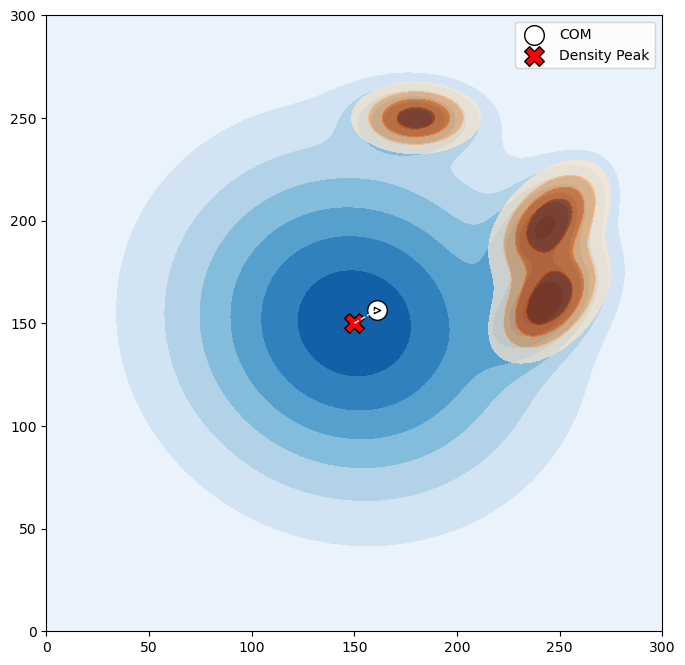

In [ ]:
N = 300
xcen = N // 2
ycen = N // 2
x = np.linspace(0, N, N)
y = np.linspace(0, N, N)
X, Y = np.meshgrid(x, y)

halo = gaussian2d(
    X, Y,
    xcen, ycen,
    amp=1.0,
    sigma_x=60,
    sigma_y=55,
    theta=20
)

# subhalos
sub1 = gaussian2d(
    X, Y,
    180, 250,
    amp=0.82,
    sigma_x=18,
    sigma_y=10,
    theta=0
)

sub2 = gaussian2d(
    X, Y,
    245, 160,
    amp=0.88,
    sigma_x=12,
    sigma_y=20,
    theta=45
)

sub3 = gaussian2d(
    X, Y,
    245, 200,
    amp=0.88,
    sigma_x=12,
    sigma_y=20,
    theta=45
)

subs = sub1 + sub2 + sub3
halo = halo + subs

ax = plt.figure(figsize=(8, 8)).add_subplot(aspect="equal")

ax.contourf(X, Y, halo, levels=10, cmap="Blues")
ax.contourf(
    X, Y, subs,
    levels=np.linspace(subs.max()*0.2, subs.max(), 5),
    cmap="Oranges",
    alpha=0.7
)

# ax.set_axis_off()

y_com, x_com = center_of_mass(halo)
ax.scatter(x_com, y_com, color="white", s=200, edgecolors="k", label='COM')
ax.scatter(xcen, ycen, color="red", s=200, edgecolors="k",
           marker="X", label='Density Peak')

ax.plot([xcen, x_com], [ycen, y_com], color="white",
        lw=1, ls='--', markeredgecolor='k')
ax.scatter(x_com, y_com, color='white', s=20, marker='>', edgecolors='k')
ax.legend()
plt.show()